In [8]:
import torch
print("CUDA available:", torch.cuda.is_available())   # Must print True
print("GPU:", torch.cuda.get_device_name(0))          # Should print RTX 4050

CUDA available: True
GPU: NVIDIA H100 NVL


In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.datasets import Food101
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from tqdm import tqdm
import os

In [ ]:
script_dir = os.path.dirname(os.path.abspath(__file__))
data_root = os.path.join(script_dir, '..', 'data')
best_model = os.path.join(script_dir, '..', 'models/resnet50/best_models/best_resnet50_model.pth')
image_output = os.path.join(script_dir, '..', 'outputs/resnet50/images/resnet50_training_curves.png')
saved_model = os.path.join(script_dir, '..', 'models/resnet50/saved_models/resnet50_food101.pth')

In [10]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [11]:
train_dataset = Food101(root=data_root, split='train', download=True, transform=train_transform)
test_dataset  = Food101(root=data_root, split='test',  download=True, transform=test_transform)

print(f"Train size: {len(train_dataset)}")   # 75,750
print(f"Test size:  {len(test_dataset)}")    # 25,250
print(f"Classes:    {len(train_dataset.classes)}")  # 101

Train size: 75750
Test size:  25250
Classes:    101


In [12]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

In [13]:
device = torch.device("cuda")
model = models.resnet50(weights=None)
model.fc = nn.Linear(2048, 101)
model = model.to(device)

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Con

In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

In [15]:
best_acc   = 0.0
patience   = 5
no_improve = 0

NUM_EPOCHS = 60
train_losses, val_accuracies = [], []

for epoch in range(1, NUM_EPOCHS + 1):

    # --- Training ---
    model.train()
    running_loss = 0.0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS}"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)

    # --- Validation ---
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch} | Loss: {avg_loss:.4f} | Val Accuracy: {val_acc:.4f}")

    scheduler.step()

    # --- Early Stopping & Best Model Saving ---
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), best_model)
        no_improve = 0
        print(f"New best model saved ({best_acc * 100:.2f}%)")
    else:
        no_improve += 1
        print(f"No improvement ({no_improve}/{patience})")

    if no_improve >= patience:
        print(f"Early stopping triggered at epoch {epoch}")
        break

# Load best model after training
model.load_state_dict(torch.load(best_model, weights_only=True, map_location=device))
model.eval()
print(f"\nTraining complete. Best Val Accuracy: {best_acc * 100:.2f}%")

Epoch 1/60: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1184/1184 [01:57<00:00, 10.11it/s]


Epoch 1 | Loss: 4.4493 | Val Accuracy: 0.0830
New best model saved (8.30%)


Epoch 2/60:   5%|████████▍                                                                                                                                                    | 64/1184 [00:06<02:02,  9.14it/s]


KeyboardInterrupt: 

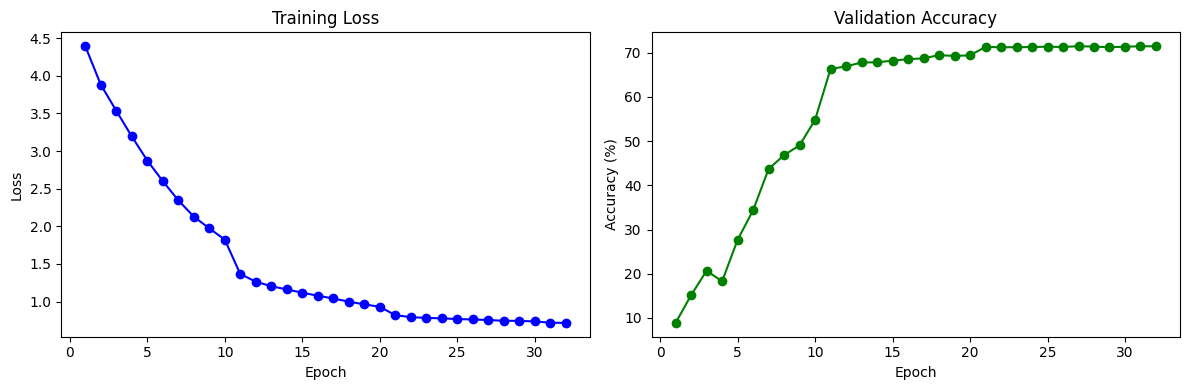

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, len(train_losses) + 1), train_losses, 'b-o')
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')

ax2.plot(range(1, len(val_accuracies) + 1), [a * 100 for a in val_accuracies], 'g-o')
ax2.set_title('Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')

plt.tight_layout()
plt.savefig(image_output, dpi=150)
plt.show()

In [10]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Evaluating"):
        images = images.to(device)
        preds = model(images).argmax(1).cpu().tolist()
        all_preds.extend(preds)
        all_labels.extend(labels.tolist())

top1 = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
print(f"\nTop-1 Accuracy: {top1 * 100:.2f}%")

print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

Evaluating: 100%|████████████████████████████████████████████████████████████████████| 395/395 [01:40<00:00,  3.94it/s]


Top-1 Accuracy: 71.45%
                         precision    recall  f1-score   support

              apple_pie       0.42      0.36      0.39       250
         baby_back_ribs       0.75      0.69      0.72       250
                baklava       0.72      0.78      0.75       250
         beef_carpaccio       0.81      0.83      0.82       250
           beef_tartare       0.69      0.68      0.69       250
             beet_salad       0.61      0.66      0.63       250
               beignets       0.77      0.81      0.79       250
               bibimbap       0.86      0.84      0.85       250
          bread_pudding       0.50      0.47      0.48       250
      breakfast_burrito       0.51      0.45      0.48       250
             bruschetta       0.66      0.64      0.65       250
           caesar_salad       0.76      0.83      0.79       250
                cannoli       0.68      0.70      0.69       250
          caprese_salad       0.72      0.73      0.72       250


In [11]:
os.makedirs('saved_models', exist_ok=True)
torch.save(model.state_dict(), saved_model)
print("Model saved!")

Model saved!


In [12]:
model_reload = models.resnet50(weights=None)
model_reload.fc = nn.Linear(2048, 101)
model_reload.load_state_dict(
    torch.load(saved_model, weights_only=True, map_location=device)
)
model_reload = model_reload.to(device)
model_reload.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 